In [1]:
import re
import os
import ast
import matplotlib
from dataclasses import dataclass, field
from collections import defaultdict
MATCH_PARA = re.compile(r'(\w+)\s+([\d.]+)')
import matplotlib.pyplot as plt
import math
from Utils import *

data_path = "quantum_network_compiler/Additional_data"
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))
absolute_path = os.path.join(parent_dir, data_path)
data_path = str(os.path.abspath(absolute_path))
data_path_to_execute = data_path + '/opt_test'
benchmark = ['xor', 'qft','grover','rca']
eval = ['look_ahead','join_map','split']

big_list = process_files_by_seed(data_path_to_execute)
averages = calculate_cross_sublist_averages(big_list)
result = classify_and_sort_averages_optimization_level(averages, eval)
diction_our = [[[],[],[],[]],[[],[],[],[]],[[],[],[],[]]]
for index, b in enumerate(benchmark):
    for a in result[b]:
        diction_our[0][index].append(a['avg_metric_t'])
        diction_our[1][index].append(a['avg_metric_w'])
        diction_our[2][index].append(a['eproverhead'])

In [2]:
benchmark = ['xor','qft','grover','rca']
big_list = process_files_by_seed(data_path_to_execute)
def grab_data(big_list):
    metric_sums = defaultdict(lambda: {'metric_t_sum': 0.0, 'metric_w_sum': 0.0,'epr_sum':0.0, 'count': 0,'in':0,'cross':0,'post':0})
    for sublist in big_list:
        for instance in sublist:
            filtered_file_p = {k: v for k, v in instance.file_p.items() if k != 'seed'}
            # if 'baseline'
            file_p_key = frozenset(filtered_file_p.items())
            metric_sums[file_p_key]['metric_t_sum'] += instance.dic_l2['time_schedule']
            metric_sums[file_p_key]['metric_w_sum'] += instance.dic_l4['avg_wait_time']
            metric_sums[file_p_key]['epr_sum'] += instance.epr
            metric_sums[file_p_key]['count'] += 1
            metric_sums[file_p_key]['in']  = instance.dic_l2['in_pair']
            metric_sums[file_p_key]['cross']  = instance.dic_l2['cross_pair']
            metric_sums[file_p_key]['post']  = instance.dic_l2['post_in_pair']
    averages = []
    for file_p_key, values in metric_sums.items():
        avg_metric_t = values['metric_t_sum'] / values['count']
        avg_metric_w = values['metric_w_sum'] / values['count']
        epr = values['epr_sum'] / values['count']
        averages.append({'file_p': dict(file_p_key), 'avg_metric_t': avg_metric_t, 'avg_metric_w': avg_metric_w, 'eproverhead':epr,'in':values['in'],'cross':values['cross'],'post':values['post']})
    return averages
result_base = classify_and_sort_averages_1(averages, 'prefix', our=1)
diction = [[[], [], [], []], [[], [], [], []], [[], [], [], []]]
for index, b in enumerate(benchmark):
    for aa in result_base[b]:
        diction[0][index].append(aa['avg_metric_t'])
        diction[1][index].append(aa['avg_metric_w'])

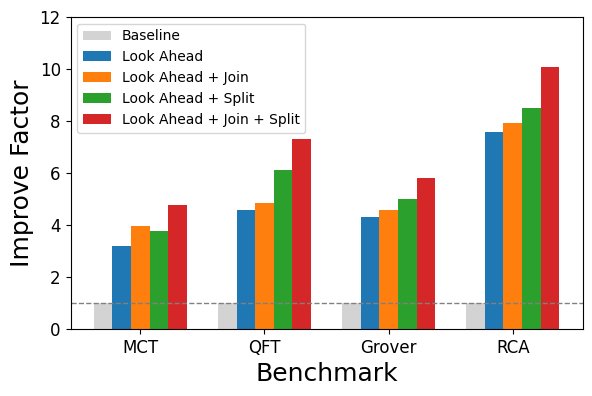

In [3]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['MCT', 'QFT', 'Grover', 'RCA']
xaxis = np.arange(len(labels)) 
width = 0.15  # 更小的宽度以容纳更多柱状图

# 原始数据
a1 = diction[0][0][0]
a2 = diction[0][1][0]
a3 = diction[0][2][0]
a4 = diction[0][3][0]

# 每层级的数据（按照索引顺序 1, 4, 5, 7）
level0_data = [1, 1, 1, 1]  # Baseline
level1_data = [a1/diction_our[0][0][1], a2/diction_our[0][1][1], a3/diction_our[0][2][1], a4/diction_our[0][3][1]]  # look ahead
level4_data = [a1/diction_our[0][0][4], a2/diction_our[0][1][4], a3/diction_our[0][2][4], a4/diction_our[0][3][4]]  # look ahead + join
level2_data = [a1/diction_our[0][0][5], a2/diction_our[0][1][5], a3/diction_our[0][2][5], a4/diction_our[0][3][5]]  # look ahead + split
level3_data = [a1/diction_our[0][0][7], a2/diction_our[0][1][7], a3/diction_our[0][2][7], a4/diction_our[0][3][7]]  # all

# 绘图
plt.figure()
plt.bar(xaxis - width*2, level0_data, width, label='Baseline', color='lightgray')
plt.bar(xaxis - width, level1_data, width, label='Look Ahead', color='C0')
plt.bar(xaxis, level4_data, width, label='Look Ahead + Join', color='C1')
plt.bar(xaxis + width, level2_data, width, label='Look Ahead + Split', color='C2')
plt.bar(xaxis + width*2, level3_data, width, label='Look Ahead + Join + Split', color='C3')

# 格式设置
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)
plt.legend(fontsize=10, loc='upper left')
plt.xticks(xaxis, labels, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 12)
plt.subplots_adjust(left=0.15, right=0.95, top=0.85, bottom=0.2)
plt.xlabel('Benchmark', fontsize=18, color='black')
plt.ylabel('Improve Factor', fontsize=18, color='black')
plt.savefig('fig/FIG_11.pdf', bbox_inches='tight')
plt.show()

